# Tugas UTS Machine Learning: Prediksi Penyakit Kardiovaskular
**Eksperimen Baseline (Model Dasar)**

Pada tahap *preliminary* ini, kami mengimplementasikan dua model dasar (*baseline*), yaitu **Support Vector Machine (SVM)** dan **Random Forest**, untuk memprediksi risiko penyakit jantung berdasarkan dataset proyek. Eksperimen ini mencakup tahapan pra-pemrosesan data secara menyeluruh hingga evaluasi metrik performa model.

## 1. Import Library dan Memuat Data
Langkah pertama adalah mengimpor semua pustaka (library) yang dibutuhkan untuk manipulasi data, pemodelan, dan visualisasi. Setelah itu, kami memuat dataset berekstensi `.csv` ke dalam Pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report #mulai bawah





# ================= Load Data =================  
# Menggunakan raw string (r) dan menyertakan nama file secara lengkap
df = pd.read_csv(r"D:\itk\semester 4\ml\project tubes\Machine-Learning-SVM\heart.csv")
print(f"Shape awal: {df.shape}\n")
display(df.head())

Shape awal: (918, 12)



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. Pembersihan Data (Data Cleansing)
Data mentah seringkali memiliki kecacatan yang dapat merusak kualitas model. Pada tahap ini kami melakukan tiga hal:
1. **Penghapusan Duplikat:** Memastikan tidak ada baris data yang berulang.
2. **Penanganan Nilai Tidak Valid:** Pada kolom `Cholesterol` dan `RestingBP`, nilai 0 tidak masuk akal secara medis. Oleh karena itu, kami mengimputasi (mengganti) nilai 0 tersebut dengan nilai median dari masing-masing kolom.
3. **Penanganan Outlier (Pencilan):** Menggunakan teknik *Winsorizing* (memotong data pada persentil 1% dan 99%) pada kolom numerik untuk mengurangi efek ekstrim dari *outlier* tanpa harus menghapus baris data.

In [2]:
# ================= Cleansing Data =================  

# Hapus duplikat
df.drop_duplicates(inplace=True)

# Nilai 0 tidak valid → ganti dengan median
for col in ['Cholesterol', 'RestingBP']:
    median = df.loc[df[col] != 0, col].median()
    df[col] = df[col].replace(0, median)

# Winsorize outlier (1%–99%)
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in num_cols:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))

print(f"Shape setelah cleansing: {df.shape}")

Shape setelah cleansing: (918, 12)


## 3. Pra-Pemrosesan Data (Data Pre-Processing)
Sebelum dimasukkan ke dalam algoritma Machine Learning, data harus disesuaikan formatnya:
* **Encoding Kategorikal:** Mengubah fitur teks menjadi angka menggunakan *One-Hot Encoding* (`pd.get_dummies`). Parameter `drop_first=True` digunakan untuk menghindari masalah *dummy variable trap* (multikolinearitas).
* **Train-Test Split:** Membagi data menjadi 80% data latih (*train*) dan 20% data uji (*test*). Kami menggunakan parameter `stratify=y` agar proporsi kelas 'Normal' dan 'Heart Disease' seimbang di kedua set.
* **Feature Scaling:** Melakukan standardisasi data menggunakan `StandardScaler`. Ini sangat **wajib** untuk algoritma SVM karena SVM sangat sensitif terhadap skala fitur (menghitung jarak antar titik data).

## 4. Pelatihan & Evaluasi Model Baseline
Kami mendefinisikan sebuah fungsi khusus `evaluate_baseline` untuk mempercepat proses pencetakan metrik performa (Accuracy, Precision, Recall, F1-Score, dan ROC-AUC). 

Selanjutnya, kami melatih dua model dengan hyperparameter *default* untuk mendapatkan performa dasar (baseline):
1. **Support Vector Machine (SVM):** Dilatih menggunakan data yang sudah di-*scale*. Kami mengatur `probability=True` agar model dapat menghitung nilai probabilitas untuk ROC-AUC.
2. **Random Forest:** Merupakan algoritma berbasis *tree* yang tidak terlalu sensitif terhadap skala, sehingga kami langsung melatihnya menggunakan data latih asli (`X_train`).

In [12]:
# ================= Evaluasi =================  
def evaluate_baseline(model, X_te, y_te, label, params):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    accuracy  = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall    = recall_score(y_te, y_pred)
    f1        = f1_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_prob)

    print("\n" + "=" * 45)
    print(f"  EVALUASI {label}")
    print("=" * 45)
    for k, v in params.items():
        print(f"  {k:<12}: {v}")
    print("-" * 45)
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print("=" * 45)
    print(f"\nClassification Report — {label}:")
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Heart Disease']))

    return y_pred, y_prob, accuracy, precision, recall, f1, auc

# ================= Memanggil Evaluasi untuk Pipeline =================  

y_pred_svm, y_prob_svm, acc_svm, pre_svm, rec_svm, f1_svm, auc_svm = evaluate_baseline(
    best_svm_pipeline, X_test, y_test,
    label="Tuned SVM (Best Model)",
    params=rs_svm.best_params_  # Ini akan otomatis mencetak parameter terbaik dari hasil tuning tadi
)

# 2. Evaluasi Tuned Random Forest
y_pred_rf, y_prob_rf, acc_rf, pre_rf, rec_rf, f1_rf, auc_rf = evaluate_baseline(
    best_rf_pipeline, X_test, y_test,
    label="Tuned Random Forest (Best Model)",
    params=rs_rf.best_params_
)


  EVALUASI Tuned SVM (Best Model)
  classifier__kernel: rbf
  classifier__gamma: 0.001
  classifier__C: 0.1
---------------------------------------------
  Accuracy  : 0.5543
  Precision : 0.5543
  Recall    : 1.0000
  F1-Score  : 0.7133
  ROC-AUC   : 0.9180

Classification Report — Tuned SVM (Best Model):
               precision    recall  f1-score   support

       Normal       0.00      0.00      0.00        82
Heart Disease       0.55      1.00      0.71       102

     accuracy                           0.55       184
    macro avg       0.28      0.50      0.36       184
 weighted avg       0.31      0.55      0.40       184


  EVALUASI Tuned Random Forest (Best Model)
  classifier__n_estimators: 300
  classifier__min_samples_split: 5
  classifier__min_samples_leaf: 2
  classifier__max_depth: None
---------------------------------------------
  Accuracy  : 0.8804
  Precision : 0.8704
  Recall    : 0.9216
  F1-Score  : 0.8952
  ROC-AUC   : 0.9377

Classification Report — Tuned 

c:\Users\DYLAN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DYLAN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DYLAN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 5. Visualisasi Hasil Evaluasi
Untuk memudahkan interpretasi dari eksperimen *baseline* di atas, kami memvisualisasikan hasil perbandingan kedua model melalui tiga grafik utama:
1. **Confusion Matrix:** Untuk melihat secara pasti jumlah tebakan Benar (True Positives/Negatives) dan Salah (False Positives/Negatives).
2. **ROC Curve:** Menunjukkan kemampuan klasifikasi model di berbagai *threshold*. Semakin kurvanya mendekati sudut kiri atas (AUC mendekati 1), semakin baik model tersebut.
3. **Bar Chart Metrik Evaluasi:** Membandingkan nilai Akurasi, Presisi, Recall, F1-Score, dan AUC antara SVM dan Random Forest secara berdampingan.

NameError: name 'y_pred_svm' is not defined

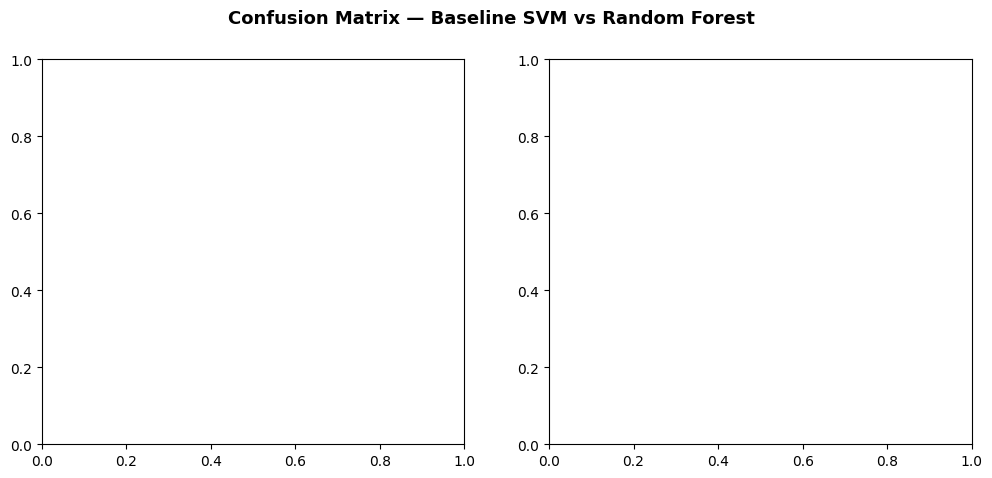

In [9]:
# ================= Visualisasi =================  

# ── Visualisasi 1: Confusion Matrix berdampingan ─────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Confusion Matrix — Baseline SVM vs Random Forest', fontsize=13, fontweight='bold')

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d',
            cmap='Blues', ax=axes1[0],
            xticklabels=['Normal', 'Heart Disease'],
            yticklabels=['Normal', 'Heart Disease'])
axes1[0].set(title=f'Baseline SVM\nAcc={acc_svm:.3f} | AUC={auc_svm:.3f}', ylabel='Actual', xlabel='Predicted')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Greens', ax=axes1[1],
            xticklabels=['Normal', 'Heart Disease'],
            yticklabels=['Normal', 'Heart Disease'])
axes1[1].set(title=f'Baseline Random Forest\nAcc={acc_rf:.3f} | AUC={auc_rf:.3f}', ylabel='Actual', xlabel='Predicted')

plt.tight_layout()
plt.show()

# ── Visualisasi 2: ROC Curve gabungan ────────────────────────────
plt.figure(figsize=(8, 6))
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_svm, tpr_svm, color='steelblue', lw=2, label=f'Baseline SVM (AUC={auc_svm:.3f})')
plt.plot(fpr_rf,  tpr_rf,  color='seagreen',  lw=2, label=f'Baseline RF  (AUC={auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.fill_between(fpr_svm, tpr_svm, alpha=0.05, color='steelblue')
plt.fill_between(fpr_rf,  tpr_rf,  alpha=0.05, color='seagreen')
plt.title('ROC Curve — Baseline SVM vs Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# ── Visualisasi 3: Bar Chart perbandingan metrik ─────────────────
plt.figure(figsize=(10, 6))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
svm_scores   = [acc_svm, pre_svm, rec_svm, f1_svm, auc_svm]
rf_scores    = [acc_rf,  pre_rf,  rec_rf,  f1_rf,  auc_rf]
x            = np.arange(len(metric_names))
width        = 0.35

bars1 = plt.bar(x - width/2, svm_scores, width, label='Baseline SVM',
                color='steelblue', alpha=0.85)
bars2 = plt.bar(x + width/2, rf_scores,  width, label='Baseline RF',
                color='seagreen',  alpha=0.85)

plt.ylim(0, 1.15)
plt.xticks(x, metric_names)
plt.title('Perbandingan Metrik — Baseline SVM vs Random Forest')
plt.ylabel('Score')
plt.legend()

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

x_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43, stratify=y
)

categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features) 
])

pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Melatih model SVM...")
pipeline_svm.fit(X_train, y_train)

print("Melatih model random forest")
pipeline_rf.fit(X_train, y_train)

print("\nPelatihan selesai pipeline siap di gunakan")

Melatih model SVM...
Melatih model random forest

Pelatihan selesai pipeline siap di gunakan


In [7]:
# ================= 1. Load Data ================= 
df = pd.read_csv(r"D:\itk\semester 4\ml\project tubes\Machine-Learning-SVM\heart.csv")

# ================= 2. Cleansing (Tanpa get_dummies!) ================= 
df.drop_duplicates(inplace=True)

for col in ['Cholesterol', 'RestingBP']:
    median = df.loc[df[col] != 0, col].median()
    df[col] = df[col].replace(0, median)

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in num_cols:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))

# ================= 3. Split Fitur & Target ================= 
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43, stratify=y
)

# ================= 4. Konfigurasi Pipeline ================= 
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Menggantikan peran get_dummies dan StandardScaler manual
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# ================= 5. Latih Pipeline ================= 
print("Melatih model SVM...")
pipeline_svm.fit(X_train, y_train)

print("Melatih model Random Forest...")
pipeline_rf.fit(X_train, y_train)

print("\nPelatihan Pipeline BERHASIL!")

Melatih model SVM...
Melatih model Random Forest...

Pelatihan Pipeline BERHASIL!


In [6]:
# Menyimpan kedua pipeline model ke dalam file fisik
joblib.dump(pipeline_svm, 'model_svm_jantung.joblib')
joblib.dump(pipeline_rf, 'model_rf_jantung.joblib')

print("Mantap! Model berhasil disimpan dan siap dibawa ke Streamlit.")

NameError: name 'pipeline_svm' is not defined

In [ ]:
# 1. Tentukan Ruang Pencarian Parameter (Hyperparameter Space)
# Karena kita menggunakan Pipeline, nama parameter WAJIB diawali dengan 'classifier__'
param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 50, 100],
    'classifier__gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'classifier__kernel': ['rbf', 'linear']
}

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# 2. Setup RandomizedSearchCV
# Kita set scoring='recall' agar mesin mencari model dengan deteksi pasien sakit terbaik
print("Menyiapkan RandomizedSearchCV...")

rs_svm = RandomizedSearchCV(
    estimator=pipeline_svm,
    param_distributions=param_grid_svm,
    n_iter=15,          # Mencoba 15 kombinasi parameter secara acak
    scoring='roc_auc',
    cv=5,               # 5-Fold Cross Validation
    random_state=42,
    n_jobs=-1           # Gunakan seluruh core CPU agar proses lebih cepat
)

rs_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_grid_rf,
    n_iter=15,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# 3. Eksekusi Pencarian (Tuning)
print("\nMemulai tuning Hyperparameter SVM... (Mohon tunggu sebentar)")
rs_svm.fit(X_train, y_train)
print("✅ Tuning SVM selesai!")
print(f"Parameter SVM Terbaik: {rs_svm.best_params_}")
print(f"Skor Recall Validasi SVM: {rs_svm.best_score_:.4f}")

print("\nMemulai tuning Hyperparameter Random Forest... (Mohon tunggu sebentar)")
rs_rf.fit(X_train, y_train)
print("✅ Tuning RF selesai!")
print(f"Parameter RF Terbaik : {rs_rf.best_params_}")
print(f"Skor Recall Validasi RF: {rs_rf.best_score_:.4f}")

# 4. Simpan model pemenang (yang sudah di-tuning) ke dalam variabel baru
best_svm_pipeline = rs_svm.best_estimator_
best_rf_pipeline = rs_rf.best_estimator_

print("\nSemua model terbaik sudah diamankan dalam variabel best_svm_pipeline dan best_rf_pipeline!")

Menyiapkan RandomizedSearchCV...

Memulai tuning Hyperparameter SVM... (Mohon tunggu sebentar)
✅ Tuning SVM selesai!
Parameter SVM Terbaik: {'classifier__kernel': 'rbf', 'classifier__gamma': 0.001, 'classifier__C': 0.1}
Skor Recall Validasi SVM: 1.0000

Memulai tuning Hyperparameter Random Forest... (Mohon tunggu sebentar)
✅ Tuning RF selesai!
Parameter RF Terbaik : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None}
Skor Recall Validasi RF: 0.9163

Semua model terbaik sudah diamankan dalam variabel best_svm_pipeline dan best_rf_pipeline!
